# PCA: Full Steps to Compute Principal Components

## Full Steps

1. **Standardize the data** — center each feature (subtract its mean) and typically scale to unit variance, so every feature contributes on the same footing.
2. **Compute the covariance matrix** of the standardized data — a square matrix capturing how every pair of features varies together.
3. **Compute eigenvalues and eigenvectors** of the covariance matrix — this is the core linear algebra step: eigenvectors give the directions of maximum variance (the principal components), eigenvalues give how much variance each direction explains.
4. **Sort** the eigenvalue/eigenvector pairs in descending order of eigenvalue, so the most important direction comes first.
5. **Choose the number of components** to keep (e.g. enough to explain 95% of cumulative variance).
6. **Project the (mean-centered) data** onto the chosen eigenvectors — this is the actual dimensionality reduction: each original sample becomes a new, shorter vector of coordinates along the principal axes.

## Why Standardize?

Covariance is scale-dependent: a feature measured in thousands (e.g. income) will have a huge variance compared to a feature measured in single digits (e.g. age), purely because of its units — not because it's actually more informative. If you skip standardization, PCA will be dominated by whichever feature happens to have the largest numeric scale, and the "directions of maximum variance" it finds will really just reflect unit choice rather than genuine structure in the data.

Standardizing (subtracting each feature's mean, dividing by its standard deviation) puts every feature on the same scale — mean 0, variance 1 — so PCA is free to find the directions that are *actually* most informative, not just the ones with the biggest numbers.

---

## Whose PCA Are We Computing?

 **PCA works on the covariance between *features* (columns), not between samples (rows).**

A 4×4 data matrix has 4 samples (rows) and 4 features (columns). The covariance matrix computed here is also 4×4 — but it's a matrix of *feature-vs-feature* covariances, not sample-vs-sample. Entry (i, j) of the covariance matrix tells you how feature i and feature j vary together *across the samples*. The eigenvectors that come out of it — the principal components — are directions in **feature space**: each principal component is a specific linear combination of the original features (column 1, column 2, column 3, column 4), not a combination of the data points themselves.

That's exactly why `rowvar=False` matters.

---

## Why `rowvar=False`?

`np.cov` needs to know which axis of the array represents "variables" (features) and which represents "observations" (samples), because it computes covariance *across observations, for each pair of variables*.

- **`rowvar=True`** (NumPy's default) assumes each **row** is a variable and each **column** is an observation.
- **`rowvar=False`** tells `np.cov` the opposite: each **row** is an observation (a sample) and each **column** is a variable (a feature) — the standard convention for tabular data (like a pandas DataFrame).

Since the `data` array has samples as rows and features as columns, `rowvar=False` is required — without it, `np.cov` would silently compute covariance between the 4 *samples* instead of the 4 *features*, giving a completely different (and meaningless, for PCA purposes) 4×4 matrix.

---

## Why Eigenvalues/Eigenvectors via `np.linalg.eig`?

The covariance matrix Σ tells you how features co-vary, but it doesn't by itself hand you "the direction of maximum variance." Eigen-decomposition is the mathematical tool that extracts exactly that: it finds vectors **v** satisfying:

A 4x4 standardized data matrix is defined. Following this, the covariance matrix of the data is computed using the `np.cov` function with the `rowvar` argument set to `False` to indicate that each row represents an observation (sample). Finally, the `eigenvalues` and `eigenvectors` of the covariance matrix are computed using the `np.linalg.eig` function.

In [59]:
import numpy as np

# Assuming the data is already standardized
data = np.array([
    [2.5, 2.4, 3.5, 2.2],
    [0.5, 0.7, 2.9, 1.9],
    [2.2, 2.9, 3.1, 3.0],
    [1.9, 2.2, 3.0, 2.1]
])

# Compute the covariance matrix
cov_matrix = np.cov(data, rowvar=False)

# Compute the eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [60]:
cov_matrix

array([[0.7825    , 0.785     , 0.1775    , 0.23666667],
       [0.785     , 0.89666667, 0.13166667, 0.35666667],
       [0.1775    , 0.13166667, 0.06916667, 0.02      ],
       [0.23666667, 0.35666667, 0.02      , 0.23333333]])

In [61]:
eigenvalues

array([1.77186614e+00, 1.80422627e-01, 1.46568536e-17, 2.93779008e-02])

In [62]:
eigenvectors

array([[-0.64548535, -0.4946439 ,  0.57887573,  0.05982446],
       [-0.70554023,  0.23815523, -0.5431304 , -0.387949  ],
       [-0.12495412, -0.37284231, -0.535187  ,  0.74762956],
       [-0.26447706,  0.7480629 ,  0.2889414 ,  0.53569268]])

Here, the equality `Σv=λv` is being checked. This is essentially verifying the characteristic equation of eigenvalues and eigenvectors using the covariance matrix (`Σ`), eigenvalues (`λ`), and eigenvectors (`v`). The `np.matmul` function is used for matrix multiplication of the covariance matrix and the eigenvectors, and this result is checked for equality against the product of eigenvalues and eigenvectors.

In [63]:
np.matmul(cov_matrix, eigenvectors)

array([[-1.14371363e+00, -8.92449525e-02, -5.55111512e-17,
         1.75751695e-03],
       [-1.25012285e+00,  4.29685929e-02,  1.66533454e-16,
        -1.13971273e-02],
       [-2.21401981e-01, -6.72691888e-02,  6.07153217e-18,
         2.19637870e-02],
       [-4.68617945e-01,  1.34967474e-01,  1.52655666e-16,
         1.57375264e-02]])

In [64]:
eigenvalues * eigenvectors

array([[-1.14371363e+00, -8.92449525e-02,  8.48449684e-18,
         1.75751695e-03],
       [-1.25012285e+00,  4.29685929e-02, -7.96058280e-18,
        -1.13971273e-02],
       [-2.21401981e-01, -6.72691888e-02, -7.84415746e-18,
         2.19637870e-02],
       [-4.68617945e-01,  1.34967474e-01,  4.23497184e-18,
         1.57375264e-02]])

The eigenvalues and corresponding eigenvectors are sorted in descending order based on the eigenvalues using `np.argsort`. This sorting is crucial as it arranges the eigenvalues (and corresponding eigenvectors) from the most to the least significant in terms of explaining the variance in the data. Next, the explained variance ratio is computed by dividing each eigenvalue by the sum of all eigenvalues. The cumulative explained variance is then computed using `np.cumsum`, which will help to understand how much variance is explained by the first `N` principal components.

In [65]:
# Sort the eigenvalues and eigenvectors by descending order of eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Output eigenvalues and eigenvectors
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# Calculate the explained variance
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Output explained variance
print("Explained Variance Ratio:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_explained_variance)

Eigenvalues: [1.77186614e+00 1.80422627e-01 2.93779008e-02 1.46568536e-17]
Eigenvectors:
 [[-0.64548535 -0.4946439   0.05982446  0.57887573]
 [-0.70554023  0.23815523 -0.387949   -0.5431304 ]
 [-0.12495412 -0.37284231  0.74762956 -0.535187  ]
 [-0.26447706  0.7480629   0.53569268  0.2889414 ]]
Explained Variance Ratio: [8.94129254e-01 9.10459009e-02 1.48248448e-02 7.39622554e-18]
Cumulative Explained Variance: [0.89412925 0.98517516 1.         1.        ]


The first two principal components are selected by extracting the first two columns of the eigenvectors matrix. The data is then projected onto a lower-dimensional subspace spanned by these two principal components using the dot product. This essentially reduces the dimensionality of the data while retaining the most significant patterns of variance.

In [66]:
# Select the first two principal components
pc1, pc2 = eigenvectors[:, 0], eigenvectors[:, 1]

# Project the data onto the lower-dimensional subspace
projected_data = np.dot(data - np.mean(data, axis=0), np.array([pc1, pc2]).T)

# Output projected data
print("Projected Data:\n", projected_data)


Projected Data:
 [[-0.73532605 -0.48988465]
 [ 1.90937863  0.09382577]
 [-1.05605056  0.52517338]
 [-0.11800203 -0.12911449]]


PCA is performed using scikit-learn's PCA implementation. Note that, the principal components computed by scikit-learn are the ones obtained using the our implementation earlier.

In [73]:
from sklearn.decomposition import PCA
# Import scikit-learn's PCA class — a ready-made, tested implementation
# of the same pipeline built by hand (standardize -> covariance ->
# eigen-decomposition -> sort -> project), so it doesn't need to be
# rewritten manually every time.  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

pca = PCA(n_components=2)
# Create a PCA object configured to keep only the top 2 principal
# components (the 2 directions with the largest eigenvalues).
# This is the "choose how many components to keep" step.
# Nothing is computed yet — this line only sets the configuration.

pca.fit(data)
# Run the actual PCA computation on `data`:
#   - center the data (subtract each feature's mean internally)
#   - compute the covariance structure of the features
#   - extract eigenvectors/eigenvalues (via SVD internally, a more
#     numerically stable route to the same eigen-decomposition)
#   - sort them by explained variance, descending
#   - keep only the top 2, storing them as learned attributes
#     (pca.components_, pca.explained_variance_, etc.)
# Note: .fit() only LEARNS the components from `data` — it does not
# return the transformed, lower-dimensional data. For that, call
# pca.transform(data), or do both at once with pca.fit_transform(data).


PCA(n_components=2)

In [74]:
# Print the principal component directions learned by scikit-learn.
# pca.components_ has shape (n_components, n_features) — each ROW is
# one principal component vector (PC1 first, PC2 second), automatically
# sorted by descending explained variance.

print("Components given by sklearn", pca.components_)

# Stack the manually computed eigenvectors pc1 and pc2 (from
# eigenvectors[:, 0] and eigenvectors[:, 1]) into a single 2x4 array,
# one row per component, so its shape matches pca.components_ and the
# two can be compared directly.
print("Components calculated by us", np.array([pc1, pc2]))

Components given by sklearn [[ 0.64548535  0.70554023  0.12495412  0.26447706]
 [-0.4946439   0.23815523 -0.37284231  0.7480629 ]]
Components calculated by us [[-0.64548535 -0.70554023 -0.12495412 -0.26447706]
 [-0.4946439   0.23815523 -0.37284231  0.7480629 ]]


In [75]:
pca.transform(data)
# Project the data onto the principal component directions that were
# already learned by pca.fit(data).
# For each sample, this computes its coordinates along PC1 and PC2 —
# i.e. the dot product of the (internally mean-centered) sample with
# each component direction — turning each original 4-feature row into
# a new 2-value row.
# This is the actual dimensionality reduction step (step 6 of the
# pipeline): it does not change or re-learn the components, it only
# maps `data` into the lower-dimensional space defined by them.
# Equivalent to the manual computation:
#   np.dot(data - np.mean(data, axis=0), np.array([pc1, pc2]).T)
# Calling pca.fit(data) followed by pca.transform(data) can be combined
# in one call as pca.fit_transform(data).

array([[ 0.73532605, -0.48988465],
       [-1.90937863,  0.09382577],
       [ 1.05605056,  0.52517338],
       [ 0.11800203, -0.12911449]])

# PCA: Toy example with the Iris dataset

We will show the use of the `PCA` method to find principal components and for dimensionality reduction.

We will use the dataset [Iris](https://es.wikipedia.org/wiki/Set_of_data_flor_iris). These are measurements on the shape of different types of iris flowers and their respective types. It will be very suitable for visualizing the principal components.

In [77]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn

# Set seaborn's plotting context to 'talk', which scales up font sizes,
# line widths, and marker sizes for all subsequent plots.
# Seaborn offers four preset contexts — 'paper', 'notebook' (default),
# 'talk', and 'poster' — each progressively larger, meant for the
# medium the plot will be viewed in (a paper vs. a presentation slide).
# 'talk' is commonly chosen here so figures stay readable when
# projected or embedded in slides, rather than sized for a small
# notebook cell.
seaborn.set_context('talk')

In [84]:
from sklearn import datasets

numpy.random.seed(5)

# Load the classic Iris dataset (150 flower samples, 3 species,
# 4 continuous measurements per sample: sepal length/width,
# petal length/width) as a scikit-learn "Bunch" object — a
# dictionary-like container holding the data, labels, feature names,
# and other metadata all together
iris = datasets.load_iris()

# Extract the feature matrix from the Bunch object: a NumPy array of
# shape (150, 4) — 150 samples (rows) x 4 features (columns). This is
# the matrix PCA will operate on.
X = iris.data

# Extract the label vector: a NumPy array of shape (150,) containing
# the species of each sample, encoded as integers (0 = setosa,
# 1 = versicolor, 2 = virginica). Not used by PCA itself (PCA is
# unsupervised and ignores labels), but useful afterward for coloring
# the projected data by species to see if PCA separates the classes.
y = iris.target

# Print the shapes of X and y as a sanity check: should show
# ((150, 4), (150,)) — confirming 150 samples, 4 features, and one
# label per sample, with X and y aligned row-for-row.
X.shape, y.shape

((150, 4), (150,))

We load our Iris dataset. The feature matrix has 150 rows and 4 columns:

$$X \in \mathbb{R}^{150 \times 4}$$

In [85]:
# Slice and display the first 2 rows of X (assumed to be the data/feature
# matrix used for PCA, e.g. loaded from a dataset like Iris).
# `[:2]` is NumPy/pandas slice notation meaning "from the start up to
# (but not including) index 2" — i.e., rows 0 and 1.
# This is a quick sanity check to peek at the raw data before running
# PCA on it: confirming the number of features (columns) and getting a
# sense of the value ranges, which matters since PCA is scale-sensitive
# (see the standardization step earlier).

X[:2]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2]])

In [86]:
# To make visualizations more easily, we will construct a DataFrame with the
# matrix of values
columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Build a dictionary mapping each column name to its corresponding
# column of data from X.
# `enumerate(columns)` pairs each column name with its index
# (0 -> 'SepalLengthCm', 1 -> 'SepalWidthCm', etc.).
# `X[:, col_id]` selects ALL rows for that one column index (feature)
# out of the (150, 4) array.
# The result is a dict like:
#   {'SepalLengthCm': array([...150 values...]),
#    'SepalWidthCm': array([...150 values...]), ...}
# — i.e., the data reshaped from "column-index access" into a
# "named-column access" form, ready to hand to pandas.
data_as_dict = {
      col_name: X[:,col_id] for col_id, col_name in enumerate(columns)
  }

# Add a 5th entry to the dictionary: the species labels (y), converted
# from integers (0, 1, 2) to strings ('0', '1', '2').
# Converting to string is done so pandas/seaborn treat this column as
# CATEGORICAL rather than numeric — important for plotting, since a
# numeric label column could otherwise be misread as a continuous
# variable (e.g. colored on a gradient scale instead of as 3 distinct
# classes) or accidentally included in numeric computations like PCA.
data_as_dict['label'] = y.astype('str')

# Convert the dictionary into a pandas DataFrame: a 150-row x 5-column
# table with columns SepalLengthCm, SepalWidthCm, PetalLengthCm,
# PetalWidthCm, and label.
# This tabular, named-column format is what seaborn's plotting
# functions expect (e.g. passing column names as x=, y=, hue=
# arguments), making it much easier to visualize the Iris data and,
# later, the PCA-projected data, colored by species.
X_df = pandas.DataFrame(data=data_as_dict)

We will first discuss what it means to "project" the data to a new dimension. The following image shows the projection $\overrightarrow a_1 = (8, 0)$ of the vector $ \overrightarrow a = (8, 5) $ onto the horizontal axis.

![picture](https://vzahorui.net/assets/images/linear_algebra/vectors_and_cosine.png)


The same type of operation is performed on the vectors of the data set. When visualizing two columns with a Scatterplot, each vector $x_i \in \mathbb{R}^4$ (which corresponds to one row), is represented only as a two-dimensional vector. You can think of each of these points as being "projected" to a single dimension to plot the distribution of each column with the side stripplots.

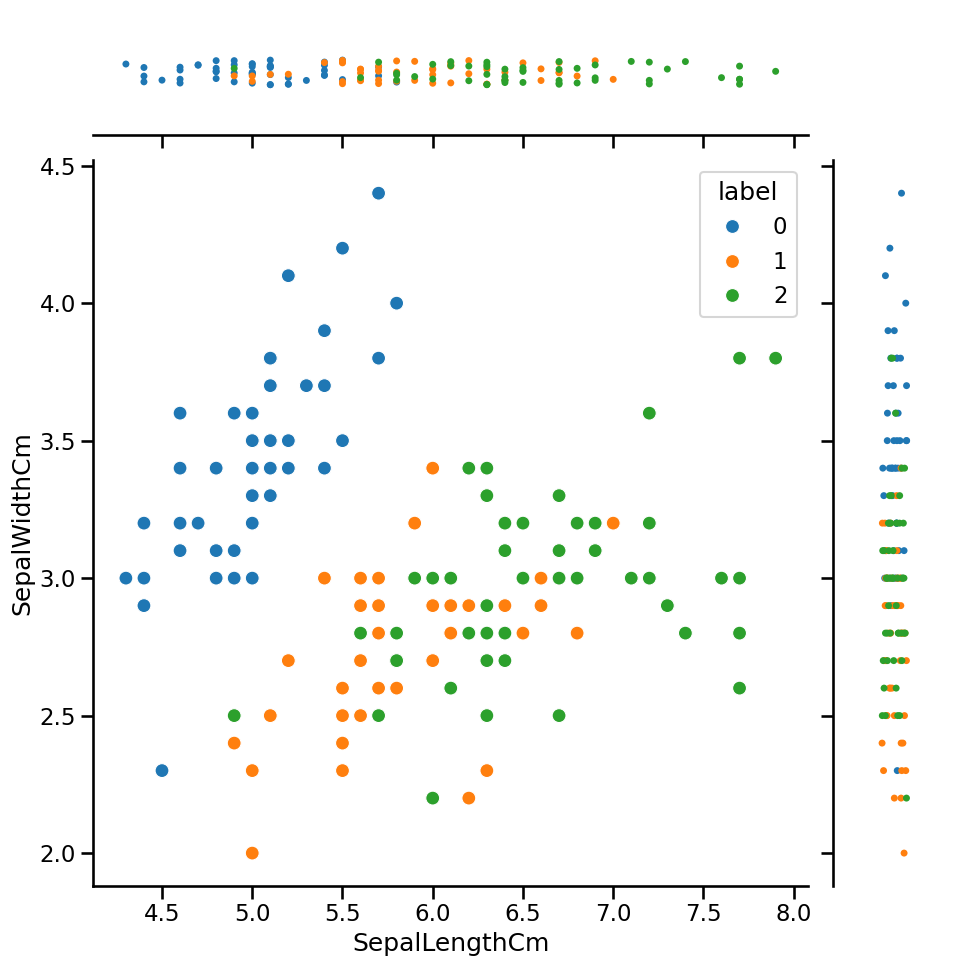

In [87]:
g = seaborn.JointGrid(data=X_df, x='SepalLengthCm', y='SepalWidthCm',
                      height=10, hue='label')
g.plot_joint(seaborn.scatterplot, s=100)
g.plot_marginals(seaborn.stripplot)

If the data is visualized through 2D Scatterplots, we can see how each pair of variables is jointly distributed. The `seaborn.pairplot` plot also shows the distribution of each variable separately using histograms.

Each of these graphs is a *projection* of the initial matrix to a smaller number of dimensions. In this case, the same original dimensions are used, that is, the pre-existing columns, but there are other forms of projection.

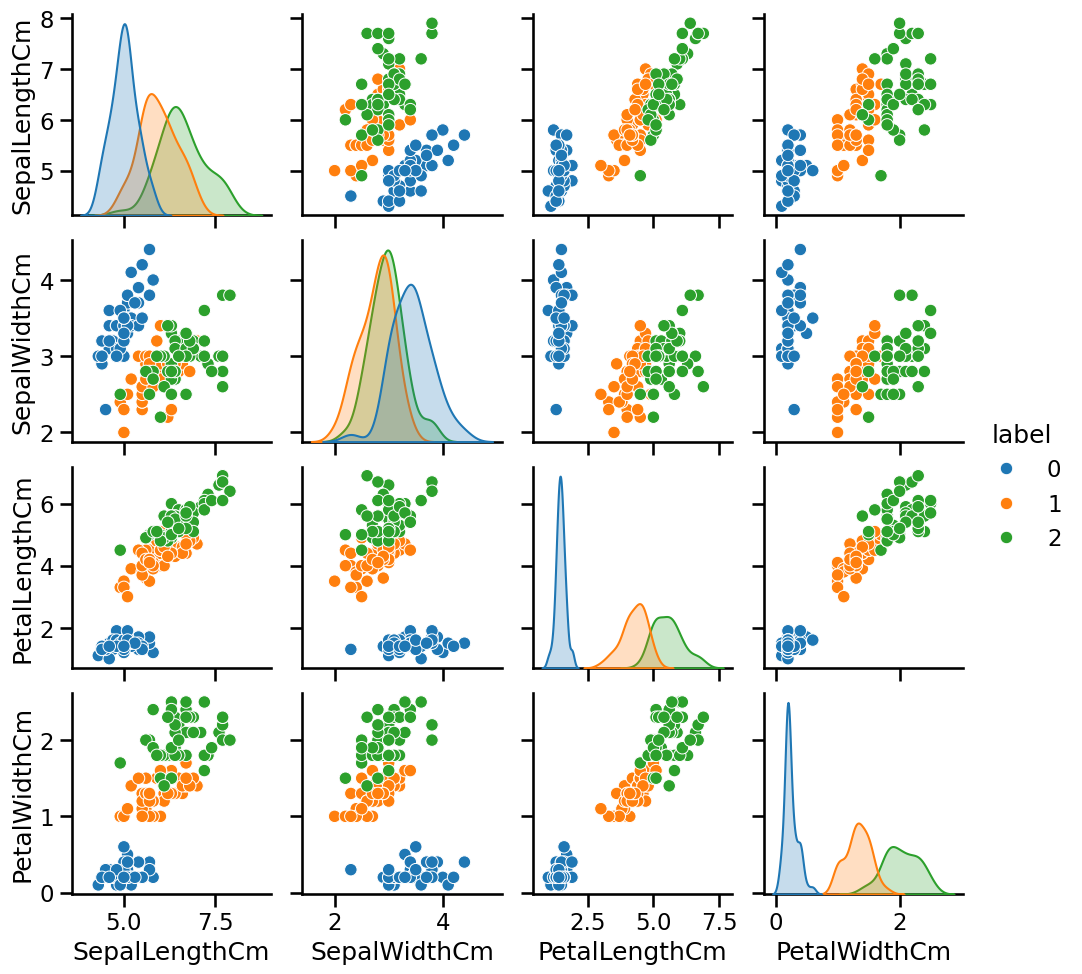

In [88]:
# Create a grid of pairwise plots for every numeric column in X_df
# (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm):
#   - Off-diagonal cells: a 2D scatterplot for each pair of features
#     (e.g. SepalLength vs. PetalWidth), showing how every pair of
#     variables is jointly distributed — one such plot per combination,
#     12 in total for 4 features (mirrored above/below the diagonal).
#   - Diagonal cells: a histogram (or KDE) of each single feature's
#     own distribution, since a feature plotted against itself isn't
#     informative as a scatterplot.
# `data=X_df` supplies the DataFrame containing the 4 features plus
# the 'label' column.
# `hue='label'` colors every point (and histogram) by species, so all
# 3 Iris classes are visually distinguishable across every subplot in
# the grid, using one consistent color scheme throughout.
# As discussed, each off-diagonal panel is a projection of the full
# 4D data down to 2 of the original dimensions — unlike PCA, which
# builds new axes as combinations of all 4 features rather than
# picking two of the existing ones.

seaborn.pairplot(data=X_df, hue='label')

# Dimensionality reduction

In order to carry out a visual analysis, we will limit ourselves to working in a single dimension. That is, it seeks to choose a single column.

**If the goal is to predict the `label` column, which column helps us best separate our data?**

Removing all columns allows you to reduce the dimensionality, but as a consequence a lot of information is lost. There are methods that combine the information from all the original columns into a single dimension. One of them is Principal Component Analysis or **PCA**.

PCA is an algebraic method that allows us to calculate the principal components of a matrix. Principal components are *addresses* in our data space $R^{4}$ (more specifically they are linear combinations of the data). These components or directions are calculated in such a way that:
* They are orthogonal, that is, they are not correlated.
* They are ordered according to the level of variance of the original data they represent.

Using these components, a linear projection of our data can be constructed to a new matrix Z where each column is now in the direction of a principal component. Then, a subset of the first $d$ columns is selected to form the matrix $Z$. From the properties of the principal components, we know that we have lost the least amount of variance from our data.

We will use the [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) implemented in the scikit-learn library. The `fit` method computes the principal components of the original array, which we can then access through the attributes of the `pca` instance.

### Example 1: Projection of $R^2$ onto $R^2$

For the purpose of visualizing the transformation, we will use only two columns of the matrix X.

When training the `PCA` class instance, sklearn takes care of centering the data by subtracting the mean. However, it is recommended to also *standardize* or at least *scale* the original array to ensure that all variables are in the same units and none have too large a weight.

In [89]:
# Choose which 2 of the 4 original columns to use for this R2 -> R2
# example, as set up in the previous cell. PetalLengthCm and
# PetalWidthCm are picked here (rather than the sepal columns) likely
# because petal measurements tend to separate the 3 Iris species more
# clearly, making the PCA visualization easier to interpret.
cols_to_project = ['PetalLengthCm', 'PetalWidthCm']

# Convert the chosen column NAMES into their corresponding column
# INDICES in the original `columns` list (['SepalLengthCm',
# 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']).
# `columns.index(col)` looks up the position of each name, e.g.
# 'PetalLengthCm' -> 2, 'PetalWidthCm' -> 3.
# This is needed because X is a plain NumPy array (not the DataFrame),
# so columns must be selected by integer position, not by name.
cols_to_project_ids = [columns.index(col) for col in cols_to_project]

# Standardize X, then keep only the 2 selected columns:
#   - X.mean(axis=0): the mean of each of the 4 columns, computed
#     down the rows (axis=0), giving one mean per feature.
#   - X - X.mean(axis=0): center each feature at 0 (subtract its own
#     mean), broadcasting the length-4 mean vector across all 150 rows.
#   - X.std(axis=0): the standard deviation of each of the 4 columns.
#   - dividing by it scales each feature to unit variance.
#   Together, (X - mean) / std standardizes ALL 4 features first
#   (mean 0, std 1 each) — this is the manual standardization step
#   flagged as recommended in the previous explanation, done here
#   even though sklearn's PCA will separately handle centering itself.
#   - [:, cols_to_project_ids]: after standardizing all 4 columns,
#     slice out only the 2 chosen ones (PetalLengthCm, PetalWidthCm),
#     giving a (150, 2) array ready for the R2 -> R2 PCA example.
X_standard = ((X - X.mean(axis=0)) / X.std(axis=0))[:,cols_to_project_ids]

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_standard)
print("Principal components")
print(pca.components_)

# The actual variance (eigenvalue) captured by each principal component,
# in the units of the (standardized) data — e.g. [1.63, 0.24] means PC1's
# spread has variance 1.63, PC2's has variance 0.24.
print("Explained variance: ")
print(pca.explained_variance_)

# The same values normalized to fractions of total variance (each
# eigenvalue divided by the sum of all eigenvalues) — e.g. [0.87, 0.13]
# means PC1 explains 87% of the variance in these 2 standardized columns,
# PC2 explains the remaining 13%.
print("Explained variance ratio")
print(pca.explained_variance_ratio_)

Principal components
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
Explained variance: 
[1.97603902 0.03738379]
Explained variance ratio
[0.98143272 0.01856728]


The following graphic represents the main components. It can be seen that these are effectively the directions of greatest variation.

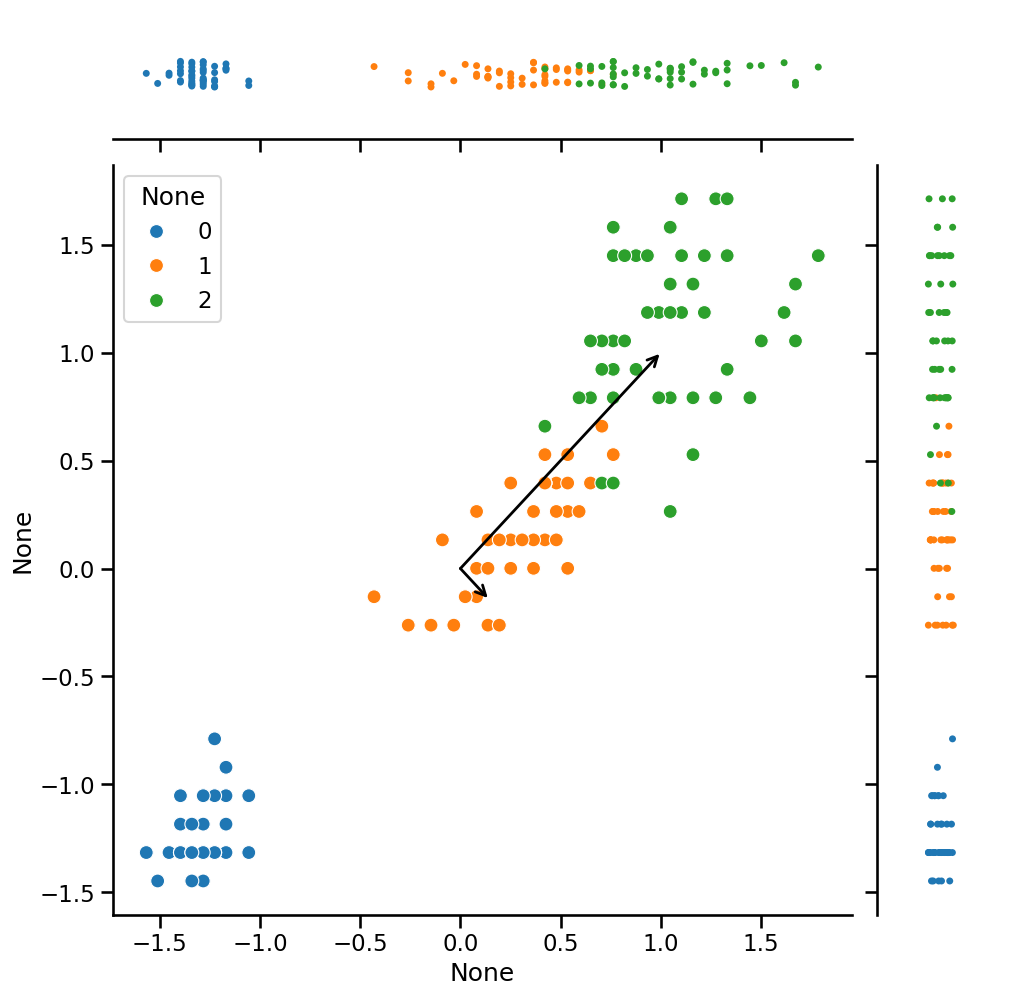

In [92]:
g = seaborn.JointGrid(x=X_standard[:,0], y=X_standard[:,1],
                      hue=X_df.label.values, height=10)
# Create a JointGrid, as before, but this time passing the standardized
# petal length (column 0) and petal width (column 1) arrays directly
# as x and y, rather than DataFrame column names — since X_standard is
# a plain NumPy array, not a DataFrame.
# hue=X_df.label.values pulls the species labels from the earlier
# DataFrame (as a plain array) to color points by species.
# height=10 sets the figure size, matching the earlier pairplot/jointplot.

g.plot_joint(seaborn.scatterplot, s=100)
# Fill the central panel with a scatterplot of the standardized petal
# length vs. petal width, colored by species, with marker size 100 —
# same as the earlier JointGrid example.

g.plot_marginals(seaborn.stripplot)
# Fill the top and right marginal panels with strip plots showing the
# 1D distribution of standardized petal length and petal width per
# species — same pattern as before.

ax = g.ax_joint.figure.axes[0]
# Grab a direct reference to the underlying matplotlib Axes object of
# the central (joint) scatterplot panel, so arrows can be drawn on top
# of it manually — seaborn's JointGrid doesn't have a built-in method
# for adding custom annotations like arrows, so this drops down to raw
# matplotlib.

for length, vector in zip(pca.explained_variance_, pca.components_):
    # Loop over each principal component, pairing its explained
    # variance (length) with its direction (vector). Since
    # pca.explained_variance_ and pca.components_ are both already
    # sorted (PC1 first, PC2 second), this iterates PC1 then PC2.

    arrowprops = dict(arrowstyle='->',
                      linewidth=2,
                      shrinkA=0, shrinkB=0)
    # Define the visual style for the arrow: a simple "->" arrowhead,
    # a line width of 2 for visibility, and shrinkA/shrinkB=0 so the
    # arrow is drawn at its full, exact length (no gap trimmed off
    # either end, which matplotlib does by default).

    v = vector * numpy.sqrt(length)
    # Scale the (unit-length) component direction by the SQUARE ROOT
    # of its explained variance — i.e. by its standard deviation, not
    # the raw variance itself. This makes the arrow's length
    # proportional to how spread out the data actually is along that
    # direction (in the same units as the data), so PC1's arrow will
    # be visibly longer than PC2's, reflecting that PC1 captures far
    # more of the spread (98.1% vs. 1.9% here).

    ax.annotate('', pca.mean_ + v, pca.mean_, arrowprops=arrowprops)
    # Draw the arrow directly on the scatterplot axes:
    #   - '' : no text label for the annotation, just the arrow itself.
    #   - pca.mean_ + v : the arrow's TIP (destination point) — starting
    #     from the data's mean and moving along the scaled component
    #     direction v.
    #   - pca.mean_ : the arrow's TAIL (starting point) — the center
    #     of the data (since X_standard is standardized/centered,
    #     pca.mean_ should be very close to [0, 0]).
    #   - arrowprops=arrowprops : applies the style defined above.
    # Net effect: two arrows are drawn from the center of the data
    # cloud, one along PC1 (long) and one along PC2 (short), visually
    # confirming that these directions align with where the data is
    # most and least spread out.


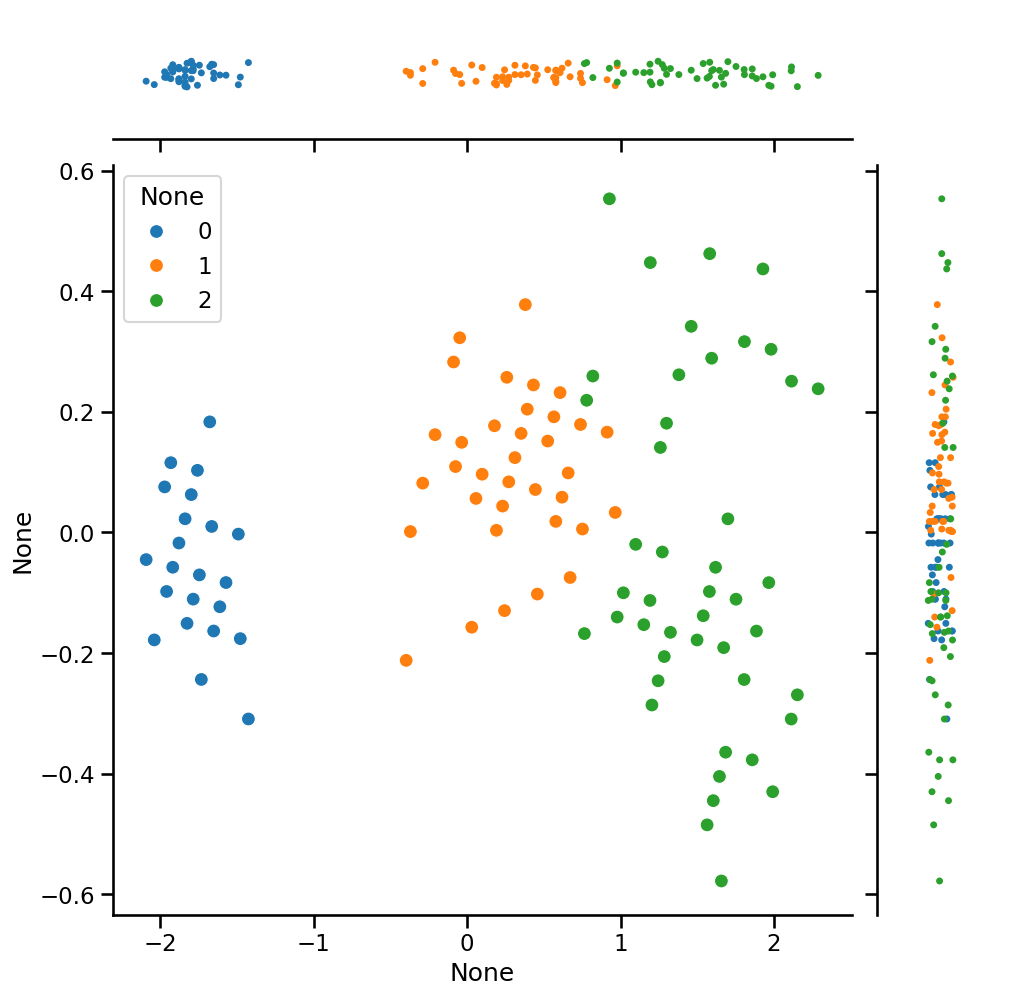

In [93]:
X_projected = pca.transform(X_standard)
# Project X_standard onto the principal component axes learned by
# pca.fit() earlier — i.e. rotate the data so its new coordinates are
# (distance along PC1, distance along PC2) instead of (petal length,
# petal width). Since this is R2 -> R2 (no dimensions dropped, both
# components kept), this is a pure ROTATION of the data around its
# mean, not a reduction — same points, same overall spread, just
# re-expressed along the two arrow directions drawn in the previous plot.

g = seaborn.JointGrid(x=X_projected[:,0], y=X_projected[:,1],
                      hue=X_df.label.values,
                      height=10)
# Create a new JointGrid using the PROJECTED coordinates: column 0 of
# X_projected (position along PC1) as x, column 1 (position along PC2)
# as y. Colored by species (hue), same size as before — set up to
# visually compare against the original (unrotated) scatterplot.

g.plot_joint(seaborn.scatterplot, s=100)
# Draw the scatterplot of the projected data in the central panel —
# same points as before, but now viewed in PCA-rotated coordinates
# instead of the original petal length/width axes.

g.plot_marginals(seaborn.stripplot)
# Draw the marginal strip plots showing the 1D distribution along PC1
# (top) and PC2 (right). Since PC1 captures ~98% of the variance, its
# marginal distribution should look noticeably wider/more spread out
# than PC2's marginal, which should look tightly clustered near 0 —
# a direct visual confirmation of the explained_variance_ratio_ values
# computed earlier.

### Example 2: Projection of $\mathbb{R}^4$ onto $\mathbb{R}^2$

In the example above, we only show how principal components allow you to project a data set to *other* dimensions, but we use the same amount.

Let's now see the result of calculating the principal components using all our columns, and then how we can project that data from $\mathbb{R}^4$ to $\mathbb{R}^2$

In [94]:
X_standard2 = ((X - X.mean(axis=0)) / X.std(axis=0))
# Standardize ALL 4 columns of X this time (SepalLengthCm,
# SepalWidthCm, PetalLengthCm, PetalWidthCm) — unlike X_standard
# earlier, there's no [:, cols_to_project_ids] slicing at the end, so
# none of the 4 columns are dropped here.
#   - X.mean(axis=0): mean of each of the 4 columns (one mean per
#     feature, computed down the rows).
#   - X - X.mean(axis=0): center each feature at 0.
#   - X.std(axis=0): standard deviation of each of the 4 columns.
#   - dividing by it scales each feature to unit variance.
# Result: X_standard2 has shape (150, 4) — same shape as the original
# X, but now every feature has mean 0 and standard deviation 1, so no
# single feature (e.g. one measured in larger units) can dominate the
# principal component calculation just because of its scale.
# This is the input for the R4 -> R2 example: all 4 standardized
# features will go into PCA, and only 2 components will be kept.

In [95]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
pca2.fit(X_standard2)
print("Principal components")
print(pca2.components_)
print("Explained variance ratio")
print(pca2.explained_variance_ratio_)

Principal components
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
Explained variance ratio
[0.72962445 0.22850762]


In [96]:
X_reduced = pca2.transform(X_standard2)
# Project all 150 standardized 4-feature samples onto the 2 principal
# components learned by pca2.fit() — turning each row from 4 numbers
# (SepalLength, SepalWidth, PetalLength, PetalWidth) into 2 numbers
# (position along PC1, position along PC2).
# Unlike Example 1's pca.transform (a pure rotation, R2 -> R2, no
# information lost), this is a genuine dimensionality REDUCTION:
# R4 -> R2, keeping the ~95.8% of variance captured by these 2
# components and discarding the ~4.2% carried by the 2 dropped ones.
# X_reduced has shape (150, 2) — ready to be scatter-plotted directly,
# since it's now low-dimensional enough to visualize on a normal 2D
# plot, colored by species, to check how well 2 components alone
# separate the 3 Iris classes.

In [97]:
X_reduced

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

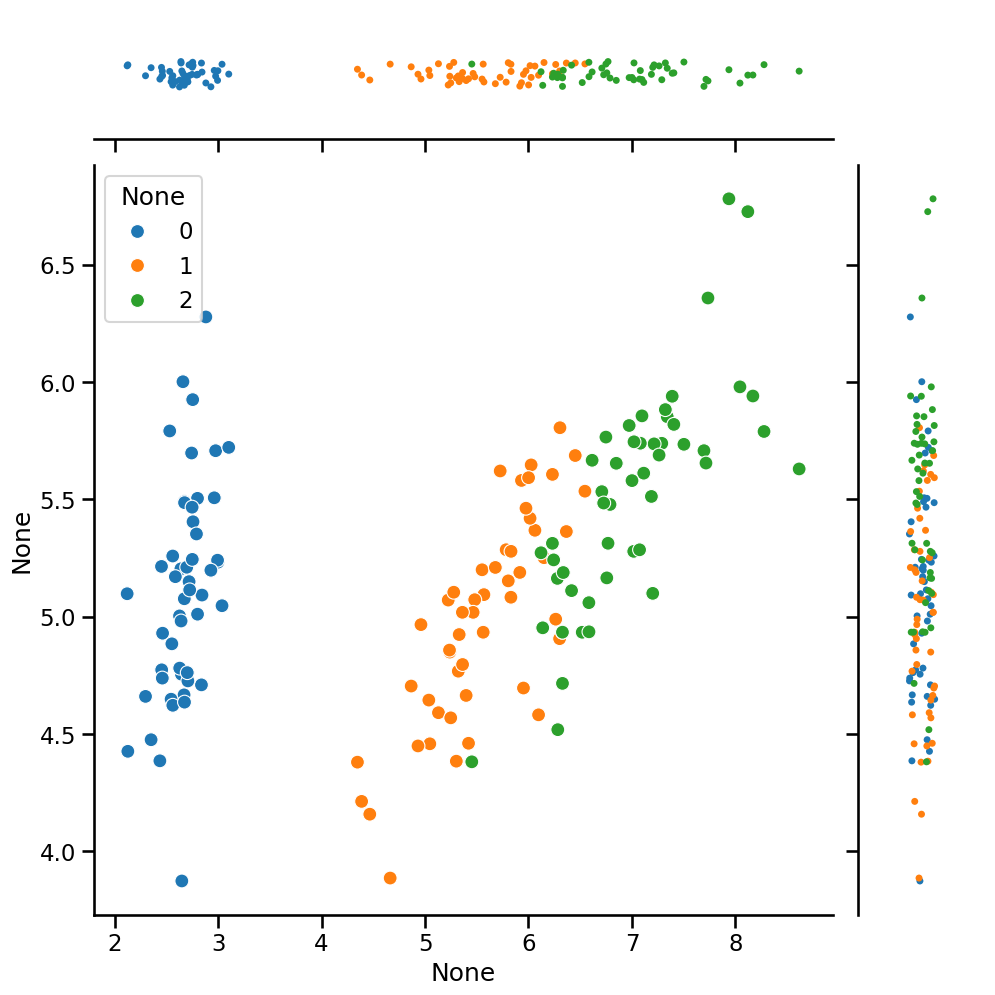

In [98]:
X_reduced = pca2.transform(X)

g = seaborn.JointGrid(x=X_reduced[:,0], y=X_reduced[:,1],
                      hue=X_df.label.values,
                      height=10)
g.plot_joint(seaborn.scatterplot, s=100)
g.plot_marginals(seaborn.stripplot)

# PCA: Melbourn Dataframe

In [100]:
melb_df = pandas.read_csv('../content/melb_data.csv') #loading the data. For loading just upload the dataset csv in the Files section. any other uploading path will fail this line.

# Display the first 3 rows of the DataFrame as a quick sanity check —
# confirming the file loaded correctly, and getting a first look at
# the available columns (e.g. Price, Rooms, Suburb, Type, Landsize,
# etc.) and their raw values before any cleaning or PCA is applied.
# Unlike the Iris data, this is real-world tabular data likely to
# contain a mix of numeric and categorical columns, missing values,
# and outliers — all things that will need handling before PCA can
# run on it (PCA requires a fully numeric matrix).
melb_df[:3]

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [102]:
feature_cols = ['Type', 'Distance', 'Bedroom2', 'Bathroom', 'Landsize', 'Regionname']
# Select a specific subset of 6 columns to work with, out of the many
# columns in the full Melbourne dataset. This mixes two kinds of
# features:
#   - numeric: Distance, Bedroom2, Bathroom, Landsize
#   - categorical (text): Type, Regionname
# This mix is exactly the "different kind of challenge" flagged
# earlier — PCA can't consume 'Type' or 'Regionname' as-is, since PCA
# requires numeric input.

feature_dict = list(melb_df[feature_cols].T.to_dict().values())
# Convert the selected columns into a list of per-row dictionaries.
# Step by step:
#   - melb_df[feature_cols]: keep only those 6 columns, dropping
#     everything else (a DataFrame with shape (n_rows, 6)).
#   - .T: transpose the DataFrame, flipping rows and columns, so now
#     each ORIGINAL ROW becomes a column, and the 6 feature names
#     become the row index.
#   - .to_dict(): convert the transposed DataFrame into a dictionary
#     of dictionaries — keyed by the (transposed) column labels, i.e.
#     the original row numbers — where each value is itself a dict of
#     {feature_name: value} for that row.
#   - .values(): discard the outer row-number keys, keeping just the
#     list of per-row {feature_name: value} dictionaries.
#   - list(...): materialize that into an actual Python list.
# Net effect: melb_df[feature_cols] (a DataFrame) becomes a list where
# each element is one house, represented as a plain dict, e.g.:
#   {'Type': 'h', 'Distance': 2.5, 'Bedroom2': 3, 'Bathroom': 1,
#    'Landsize': 150, 'Regionname': 'Northern Metropolitan'}
# This "list of dicts" format is a common intermediate representation
# needed for tools that expect one-dict-per-sample rather than a
# DataFrame — most likely, as the next step, a DictVectorizer (from
# scikit-learn), which can automatically one-hot encode the
# categorical fields (Type, Regionname) while passing numeric fields
# through unchanged — solving the "PCA needs numeric input" problem.

feature_dict[:2]
# Display the first 2 house-dictionaries as a sanity check, to confirm
# the conversion worked and see the mixed numeric/categorical values
# per sample before vectorizing.

[{'Type': 'h',
  'Distance': 2.5,
  'Bedroom2': 2.0,
  'Bathroom': 1.0,
  'Landsize': 202.0,
  'Regionname': 'Northern Metropolitan'},
 {'Type': 'h',
  'Distance': 2.5,
  'Bedroom2': 2.0,
  'Bathroom': 1.0,
  'Landsize': 156.0,
  'Regionname': 'Northern Metropolitan'}]

In [104]:
from sklearn.feature_extraction import DictVectorizer
# Import DictVectorizer, a scikit-learn utility that converts a list
# of feature dictionaries (like feature_dict) into a numeric matrix —
# exactly the format PCA needs, and exactly the tool set up for by the
# previous "list of dicts" conversion.

vec = DictVectorizer()
# Create a DictVectorizer instance. By default it produces a sparse
# matrix (efficient when many entries are 0, which is common once
# categorical columns are expanded — see below).

feature_matrix = vec.fit_transform(feature_dict)
# Fit the vectorizer to feature_dict and transform it into a numeric
# matrix in one step. What actually happens to each field:
#   - Numeric fields (Distance, Bedroom2, Bathroom, Landsize) are kept
#     as-is, one column each.
#   - Categorical/string fields (Type, Regionname) are automatically
#     ONE-HOT ENCODED: DictVectorizer scans all distinct values seen
#     across the dataset (e.g. Type: 'h', 'u', 't'; Regionname:
#     'Northern Metropolitan', 'Western Metropolitan', ...) and creates
#     one new binary column per distinct value, named
#     'Type=h', 'Type=u', 'Regionname=Northern Metropolitan', etc.
#     Each row gets a 1 in the column matching its actual value for
#     that field, and 0 in all the other columns for that field.
# This is exactly what solves PCA's "numeric input only" requirement:
# every original column — numeric or categorical — becomes one or more
# plain numeric columns.
#
# For example, on a small sample of 2 houses this produces an 8-column
# matrix:
#   ['Bathroom', 'Bedroom2', 'Distance', 'Landsize',
#    'Regionname=Northern Metropolitan', 'Regionname=Western Metropolitan',
#    'Type=h', 'Type=u']
#   [[  1.,   3.,  2.5, 150.,  1.,  0.,  1.,  0.],
#    [  1.,   2.,  3.1,   0.,  0.,  1.,  0.,  1.]]
# — the 4 numeric fields pass through unchanged, while Type and
# Regionname each expand into one 0/1 column per category seen.
#
# feature_matrix is returned as a SciPy sparse matrix (not a plain
# NumPy array), since one-hot encoding tends to create many zeros —
# e.g. with many distinct suburbs/regions in Regionname, most columns
# for most rows will be 0. This is memory-efficient, but note that
# PCA (as used earlier via sklearn's PCA class) typically expects a
# dense array — so a later step will likely need
# feature_matrix.toarray() (or .todense()) before fitting PCA on it,
# unless TruncatedSVD (PCA's sparse-friendly counterpart) is used
# instead.

## Dimensionality reduction with PCA

In the following rows, we will apply [PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca) to reduce the dimensionality of the data set to 2 dimensions. A process similar to that seen in the 06 notebook will be followed.

In [105]:
X = feature_matrix.todense()
# Convert the sparse matrix (from DictVectorizer) into a DENSE matrix,
# i.e. actually storing every 0 explicitly instead of just the nonzero
# entries. This is needed because the next line (mean-centering) will
# turn most of those zeros into nonzero values anyway, so there's no
# memory benefit to staying sparse past this point — and functions
# like standard deviation/mean generally expect dense input.
# Note: .todense() returns a numpy.matrix (a legacy 2D-only subtype),
# not a plain numpy.ndarray — usually behaves the same for this kind
# of arithmetic, but can occasionally cause subtle shape/broadcasting
# surprises later (e.g. X.mean(axis=0) returning a (1, n) matrix
# instead of a flat (n,) array). Using .toarray() instead of
# .todense() avoids that and is generally the safer choice, though
# .todense() will still work for what follows here.

scaled_dense_feature_matrix = ((X - X.mean(axis=0)) / X.std(axis=0))
# Standardize every column of X — same pattern as X_standard2 for
# Iris: subtract each column's mean, divide by each column's standard
# deviation, so every feature (both the original numeric columns and
# every one-hot encoded category column) ends up with mean 0 and
# standard deviation 1.
# This is the step that prevents Landsize (raw values in the hundreds/
# thousands) from dominating the 0/1 one-hot columns purely due to scale,
# as flagged before.
#
# One practical gotcha specific to one-hot columns: if any category is
# extremely rare or a particular column ends up constant across all
# rows (std = 0), this division produces NaN/inf for that column
# (division by zero) — worth a quick check (e.g.
# np.isnan(scaled_dense_feature_matrix).any()) if PCA errors out or
# produces unexpected NaNs downstream.

In [107]:
from sklearn.decomposition import PCA
# Re-import PCA (already imported earlier in the notebook, but often
# repeated in each section/cell for readability or reproducibility).

pca = PCA(n_components=10)
# Create a PCA instance keeping the top 10 principal components.

pca.fit(np.asarray(scaled_dense_feature_matrix))
# np.asarray(...) converts scaled_dense_feature_matrix from a
# numpy.matrix (the type returned by .todense() earlier) into a plain
# numpy.ndarray — avoiding the numpy.matrix quirks mentioned before
# (e.g. unexpected 2D shapes from operations that normally return 1D).
# pca.fit(...) then learns the 10 principal components from this
# standardized, fully numeric (one-hot + scaled) feature matrix —
# same fitting process as before, just with more components kept
# and on the Melbourne housing features instead of Iris.

proyected_features = pca.transform(np.asarray(scaled_dense_feature_matrix))
# Project the data onto the 10 fitted components, reducing each row
# from its original number of columns (numeric + one-hot columns) down
# to 10 values. Note this line passes scaled_dense_feature_matrix
# directly (still a numpy.matrix), not wrapped in np.asarray(...) like
# the .fit() call above — inconsistent, but .transform() will likely
# still work since it accepts array-likes; the asarray conversion in
# the previous line was probably more about avoiding a specific issue
# during fitting.

proyected_features.shape
# Display the shape of the result — expected to be (n_samples, 10),
# confirming the reduction: each house is now represented by 10 numbers
# instead of the original count of numeric + one-hot columns.

(13580, 10)

In [108]:
np.cumsum(pca.explained_variance_ratio_)
# Compute the running (cumulative) sum of the explained variance ratio
# across the 10 kept components, in order (PC1, PC1+PC2, PC1+PC2+PC3, ...).
# e.g. if explained_variance_ratio_ were [0.30, 0.18, 0.12, ...], this
# returns [0.30, 0.48, 0.60, ...] — element i tells you the TOTAL
# fraction of variance captured by using the first (i+1) components
# together, not just component i alone.
#
# This is the practical tool for answering the question left open by
# using n_components=10 instead of 2 earlier: it lets you see, at a
# glance, how many components are actually needed to capture "enough"
# variance (commonly 90% or 95%) before committing to a final number
# for visualization or downstream modeling — e.g. checking at which
# index this array first crosses 0.95, rather than guessing 2 (as
# Iris happened to work well) or 10 (an arbitrary upper bound) upfront.

array([0.18476163, 0.29321535, 0.39079947, 0.47704563, 0.56049981,
       0.6341613 , 0.70418017, 0.7712938 , 0.83818751, 0.902297  ])

Text(0.5, 0, 'Components')

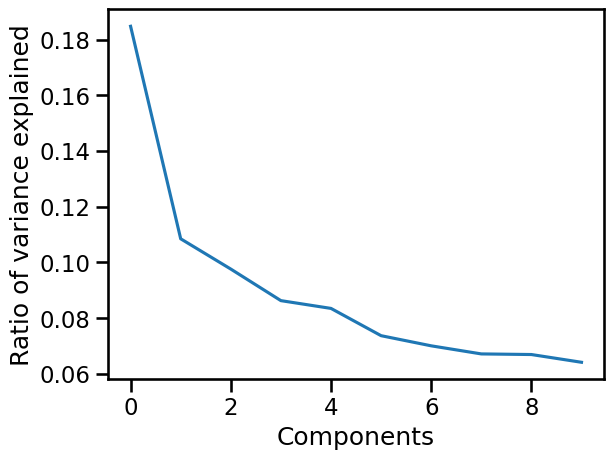

In [109]:
seaborn.lineplot(x=range(pca.n_components),
                 y=pca.explained_variance_ratio_)
# Draw a line plot of explained variance ratio (y) against component
# index (x): x goes from 0 to pca.n_components - 1 (i.e. 0 through 9,
# since n_components=10), and y is the (non-cumulative) fraction of
# variance each individual component explains on its own.
# This is commonly called a "scree plot" — used to visually spot
# where the ratio drops off sharply and levels out, which suggests how
# many components carry meaningful signal versus how many are mostly
# noise.

plt.ylabel("Ratio of variance explained")
# Label the y-axis for clarity — reminding the reader that each point
# represents that single component's individual share of total
# variance (not the cumulative sum from the previous cell).

plt.xlabel("Components")
# Label the x-axis — each tick corresponds to one principal component,
# in order from most variance explained (component 0 / PC1) to least
# (component 9 / PC10).